# Hyperparameter Tuning

## Overview

Hyperparameters are model settings that are not learned from training data — they control model complexity, regularisation, and learning dynamics. Selecting them well is as important as choosing the model family.

**Tuning strategies:**

| Strategy | When to use | Pros/Cons |
|---|---|---|
| Grid Search | Small parameter spaces | Exhaustive but expensive |
| Random Search | Medium spaces | Often matches grid at 10-20% cost |
| Halving Search | Large spaces | Eliminates bad configs early |
| Bayesian Optimisation | Expensive models | Sample-efficient |

**Key principle:** hyperparameter tuning is itself a model selection step. The CV score obtained during tuning is optimistically biased for the selected configuration — use nested CV or a held-out test set for honest final evaluation.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
    HalvingRandomSearchCV, StratifiedKFold, cross_val_score, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy.stats import randint, uniform
import time

rng = np.random.default_rng(42)
n = 400
elevation  = rng.uniform(50, 400, n)
nitrate    = rng.gamma(2, 2, n)
richness   = 25 - 0.03*elevation - 0.7*nitrate + rng.normal(0, 3, n)
log_odds   = -1.5 + 0.003*elevation - 0.15*nitrate + 0.07*richness
y = (1/(1+np.exp(-log_odds)) > 0.5).astype(int)
X = np.column_stack([elevation, nitrate, richness])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                            stratify=y, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Train={len(X_tr)}, Test={len(X_te)}, prevalence={y.mean():.2f}")
     

Train=300, Test=100, prevalence=0.33


---
## Grid Search

In [2]:
param_grid = {
    "n_estimators":  [50, 100, 200],
    "max_depth":     [3, 5, None],
    "min_samples_leaf": [1, 5, 10],
}
gs = GridSearchCV(RandomForestClassifier(random_state=42),
                  param_grid, cv=cv, scoring="roc_auc",
                  n_jobs=-1, verbose=0)
t0 = time.time()
gs.fit(X_tr, y_tr)
print(f"Grid search: {len(gs.cv_results_['mean_test_score'])} configs in {time.time()-t0:.1f}s")
print(f"Best params: {gs.best_params_}")
print(f"Best CV AUC: {gs.best_score_:.4f}")
print(f"Test AUC:    {roc_auc_score(y_te, gs.predict_proba(X_te)[:,1]):.4f}")

Grid search: 27 configs in 9.6s
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV AUC: 0.9770
Test AUC:    0.9982


---
## Random Search

Random search: 50 configs in 18.3s
Best params: {'max_depth': 7, 'max_features': np.float64(0.3144091460070617), 'min_samples_leaf': 2, 'n_estimators': 393}
Best CV AUC: 0.9718
Test AUC:    0.9991


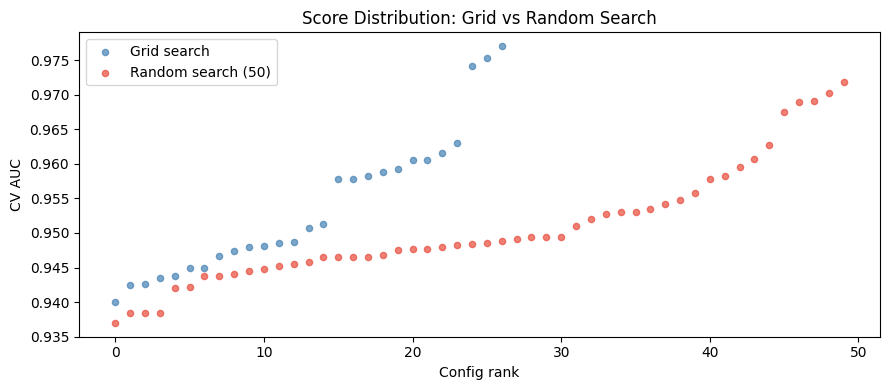

In [3]:
param_dist = {
    "n_estimators":     randint(50, 500),
    "max_depth":        [3, 5, 7, 10, None],
    "min_samples_leaf": randint(1, 20),
    "max_features":     uniform(0.3, 0.7),
}
rs = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                         param_dist, n_iter=50, cv=cv,
                         scoring="roc_auc", n_jobs=-1,
                         random_state=42, verbose=0)
t0 = time.time()
rs.fit(X_tr, y_tr)
print(f"Random search: 50 configs in {time.time()-t0:.1f}s")
print(f"Best params: {rs.best_params_}")
print(f"Best CV AUC: {rs.best_score_:.4f}")
print(f"Test AUC:    {roc_auc_score(y_te, rs.predict_proba(X_te)[:,1]):.4f}")
# Compare score distributions
fig, ax = plt.subplots(figsize=(9,4))
ax.scatter(range(len(gs.cv_results_["mean_test_score"])),
           sorted(gs.cv_results_["mean_test_score"]),
           s=20, alpha=0.7, color="steelblue", label="Grid search")
ax.scatter(range(len(rs.cv_results_["mean_test_score"])),
           sorted(rs.cv_results_["mean_test_score"]),
           s=20, alpha=0.7, color="#e74c3c", label="Random search (50)")
ax.set_xlabel("Config rank"); ax.set_ylabel("CV AUC")
ax.set_title("Score Distribution: Grid vs Random Search")
ax.legend(); plt.tight_layout(); plt.show()

---
## Nested Cross-Validation for Honest Evaluation

In [4]:
from sklearn.model_selection import cross_val_score
# Inner CV: tune; outer CV: evaluate
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Using random search inside outer CV
nested_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist, n_iter=20, cv=inner_cv,
    scoring="roc_auc", n_jobs=-1, random_state=42)
nested_scores = cross_val_score(nested_rs, X_tr, y_tr,
                                 cv=outer_cv, scoring="roc_auc", n_jobs=-1)
# Non-nested (biased)
non_nested_scores = cross_val_score(
    RandomForestClassifier(**rs.best_params_, random_state=42),
    X_tr, y_tr, cv=outer_cv, scoring="roc_auc")
print(f"Nested CV AUC:     {nested_scores.mean():.4f} +/- {nested_scores.std():.4f}")
print(f"Non-nested CV AUC: {non_nested_scores.mean():.4f} +/- {non_nested_scores.std():.4f}")
print(f"Optimism bias:     {non_nested_scores.mean()-nested_scores.mean():.4f}")
print("Non-nested inflates performance by reusing the data that selected the params")

Nested CV AUC:     0.9735 +/- 0.0221
Non-nested CV AUC: 0.9718 +/- 0.0228
Optimism bias:     -0.0017
Non-nested inflates performance by reusing the data that selected the params


In [5]:
# Halving search: eliminates bad configs early with growing data
try:
    hs = HalvingRandomSearchCV(
        RandomForestClassifier(random_state=42),
        param_dist, factor=3, cv=cv,
        scoring="roc_auc", n_jobs=-1,
        random_state=42, verbose=0)
    t0 = time.time()
    hs.fit(X_tr, y_tr)
    print(f"Halving search: {time.time()-t0:.1f}s")
    print(f"Best params: {hs.best_params_}")
    print(f"Best CV AUC: {hs.best_score_:.4f}")
    print(f"Test AUC:    {roc_auc_score(y_te, hs.predict_proba(X_te)[:,1]):.4f}")
    # Show resources used per round
    results = pd.DataFrame(hs.cv_results_)
    for r in results["iter"].unique():
        sub = results[results["iter"]==r]
        print(f"  Round {r}: {len(sub)} configs, {sub['n_resources'].iloc[0]} samples each")
except Exception as e:
    print(f"HalvingRandomSearchCV: {e}")
    print("Available in sklearn >= 0.24; use RandomizedSearchCV as fallback")

c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(
c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan 0.86870701 0.91782407 0.90810185
 0.95601852 0.96226852]
  warnings.warn(
c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        

Halving search: 7.5s
Best params: {'max_depth': 5, 'max_features': np.float64(0.5976091121438712), 'min_samples_leaf': 10, 'n_estimators': 309}
Best CV AUC: 0.9572
Test AUC:    0.9900
  Round 0: 15 configs, 20 samples each
  Round 1: 5 configs, 60 samples each
  Round 2: 2 configs, 180 samples each


---

## Common Pitfalls

**1. Using the tuned CV score as the test performance estimate**  
The CV score obtained during grid/random search is optimistically biased for the chosen hyperparameter configuration — the same data was used for both selection and evaluation. Always evaluate the tuned model on a truly held-out test set or use nested CV.

**2. Running grid search over a wide grid and reporting only the best result**  
Searching 1,000 configurations and reporting the best is analogous to running 1,000 hypothesis tests and reporting only significant ones. The best CV score will overfit to CV noise. Use random search with a modest n_iter and validate on a test set.

**3. Not fixing random_state in RandomizedSearchCV**  
Without a fixed random seed, different runs sample different configurations and produce different best parameters. Always set `random_state` for reproducibility, especially in collaborative or reported work.

**4. Tuning hyperparameters before establishing a baseline**  
Extensive tuning of a fundamentally wrong model family is wasted effort. Fit a default configuration first, check that performance exceeds a naive baseline, and only then invest in tuning.

**5. Treating the best parameters from one dataset as transferable**  
Optimal hyperparameters depend on the specific dataset — its size, noise level, and feature structure. Parameters tuned on a training set of 500 samples may be suboptimal when the full dataset grows to 5,000. Re-tune when the dataset changes substantially.

---
*python_methods_library - Samantha McGarrigle*